# Ego-net project
dy Daniil Koptyov (dpkoptyov@edu.hse.ru)

## Imports

In [2]:
# pip install -Uq pip setuptools wheel
# pip install -Uq numpy pandas networkx matplotlib scipy

In [3]:
import requests
import networkx as nx
import time
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter
from IPython.display import clear_output


## Get secrets

In [4]:
with open("secrets.json") as f:
    secrets = json.load(f)
    my_user_id = secrets["my_user_id"]
    version = secrets["version"]
    my_access_token = secrets["my_access_token"]

## VK API requests

In [5]:
# inspired by https://habr.com/ru/articles/263313/
def get_friends_ids(user_id, access_token=my_access_token, version=version):
    
    friends_url = (
        'https://api.vk.com/method/friends.get?'
        'user_id={}&'
        'access_token={}&'
        'v={}'
        )

    json_response = requests.get(friends_url.format(user_id, access_token, version)).json()
    
    if json_response.get('error'):
        print(json_response.get('error'))
        return list()
    return json_response[u'response'][u'items']

In [6]:
# graph = {}
# friend_ids = get_friends_ids(my_user_id)  # ваш user id, для которого вы хотите построить граф друзей.
# for friend_id in friend_ids:
#     time.sleep(0.3)
#     print('Processing id: ', friend_id)
#     graph[friend_id] = get_friends_ids(friend_id)


In [7]:
# len(list(node for node, neighbors in graph.items() if len(neighbors) > 0))

## Save graph

In [8]:
# # drop private profiles
# private_profiles = set()

# for node, neighbors in graph.items():
#     if len(neighbors) == 0:
#         private_profiles.add(node)

# public_profiles = list(set(friend_ids) - private_profiles)

# len(public_profiles)

In [9]:
# g = nx.Graph(directed=False)
# for friend_id in public_profiles:
#     g.add_node(friend_id)
#     for ffriend_id in graph[friend_id]:
#         if friend_id != ffriend_id and ffriend_id in public_profiles:
#             g.add_edge(friend_id, ffriend_id)

In [10]:
# nx.write_gml(g, 'ego_net.gml')

## Network summary
1. The network is the ego network of my profile in vk.com. Data is collected using api.vk.com. I select only public profiles to analyse here, preventing large numbers of low degree nodes with private profiles.
2. Nodes are my friends' user_ids (obviously excluding me) and edge relation is for 2 users to be friends
3. There are 123 nodes and 371 edges
4. The net is a homogeneous unweighted undirected graph
5. There are no attributes neither for nodes nor for edges
6. The degree distribution scatter plot shows that the net is scale free (heavy tail)
7. The GCC of net satisfies to small-world property. Nevertheless the random graph show supersmall-world
8. The net demonstrates high clustering, around 9 times greater clustering coefficient than in random net
9. It looks to me that there are 4 or 5 strong communities

In [11]:
g = nx.read_gml('ego_net.gml')

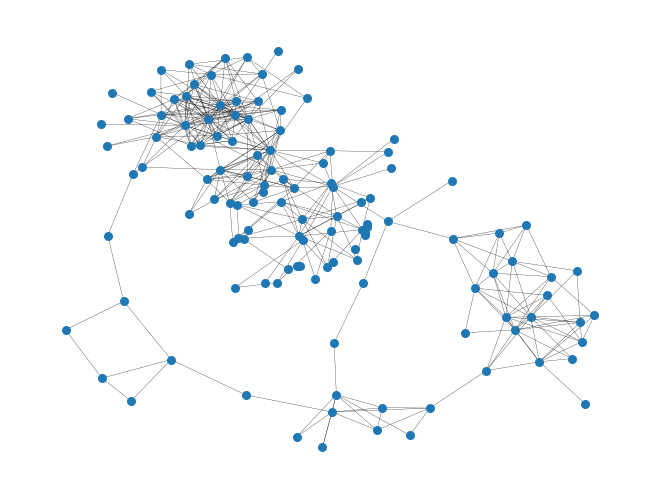

In [12]:
# plot GCC
pos = nx.layout.kamada_kawai_layout(g)
nx.draw(g, pos, node_size=30, with_labels=False, width=0.2)


In [13]:
# numbers of nodes and edges
num_n = len(g.nodes)
num_e = len(g.edges)
num_n, num_e

(123, 371)

In [14]:
# Generate random graph
random_g = nx.gnm_random_graph(123, num_e, seed=37)
print("Random graph #nodes =", len(random_g.nodes), "  #edges =", len(random_g.edges))

Random graph #nodes = 123   #edges = 371


In [15]:
# numbers of isolated nodes
len(list(node for node in g.nodes if nx.degree(g, node) == 0))

11

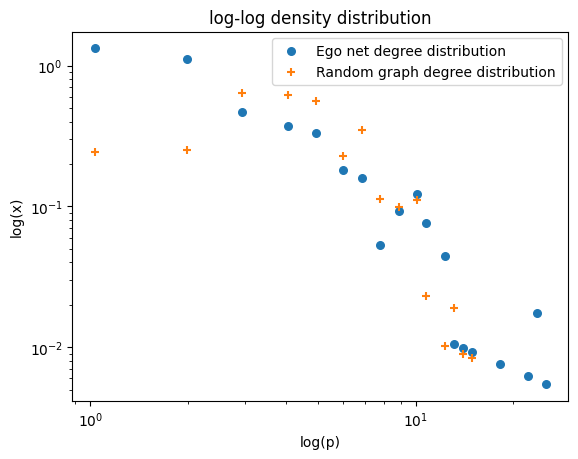

In [16]:
# power law
degrees = list(dict(nx.degree(g)).values())
n_bins = 50

deg_max = np.max(degrees)
x_space = np.geomspace(1, deg_max, n_bins + 1)

hist, bin_edges = np.histogram(degrees, bins=x_space, density=True)
bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2
plt.scatter(bin_centers[hist > 0], hist[hist > 0], marker="o", s=30, label='Ego net degree distribution')

# random law
random_degrees = list(dict(nx.degree(random_g)).values())

random_hist, _ = np.histogram(random_degrees, bins=x_space, density=True)
plt.scatter(bin_centers[random_hist > 0], random_hist[random_hist > 0], marker="+", s=30, label='Random graph degree distribution')

plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.title("log-log density distribution")
plt.xlabel("log(p)")
plt.ylabel("log(x)")
plt.show()


In [17]:
# Average distance
gcc = nx.subgraph(g, max(nx.connected_components(g), key=len))

l = nx.average_shortest_path_length(gcc)  # noqa: E741
print(l, "~", np.log(len(gcc)))
print(f"|V(GCC)| = {len(gcc)}")

# Random graph distance
random_gcc = nx.subgraph(random_g, max(nx.connected_components(random_g), key=len))

random_l = nx.average_shortest_path_length(random_gcc)  # noqa: E741
print(random_l, "!~", np.log(len(random_gcc)))
print(f"|V(GCC)| = {len(random_gcc)}")


4.430841924398625 ~ 4.574710978503383
|V(GCC)| = 97
2.8431294149007065 !~ 4.812184355372417
|V(GCC)| = 123


In [18]:
# Clustering coefficient
clustering = nx.average_clustering(g)
random_clustering = nx.average_clustering(random_g)
p = num_e * 2 / (num_n * (num_n - 1))

print(f"Clustering coefficient: {clustering:.2f}")
print(f"Random graph clustering coefficient: {random_clustering:.2f} ~ {p:.2f} (probability)")
print(f"My network is ~{clustering / random_clustering:.0f} more clustered than random graph")

Clustering coefficient: 0.47
Random graph clustering coefficient: 0.05 ~ 0.05 (probability)
My network is ~9 more clustered than random graph


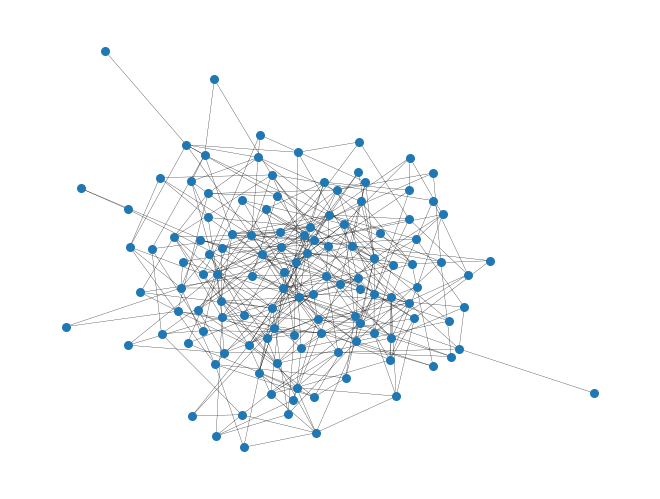

In [19]:
nx.draw(random_gcc, node_size=30, with_labels=False, width=0.2)

In [20]:
def attach(node, G, m):
    edges = []
    for edge in G.edges:
      edges.extend(edge)

    targets = set()
    while len(targets) < m:
      t = edges[np.random.randint(len(edges))]
      targets.add(t)

    for t in targets:
      G.add_edge(node, t)

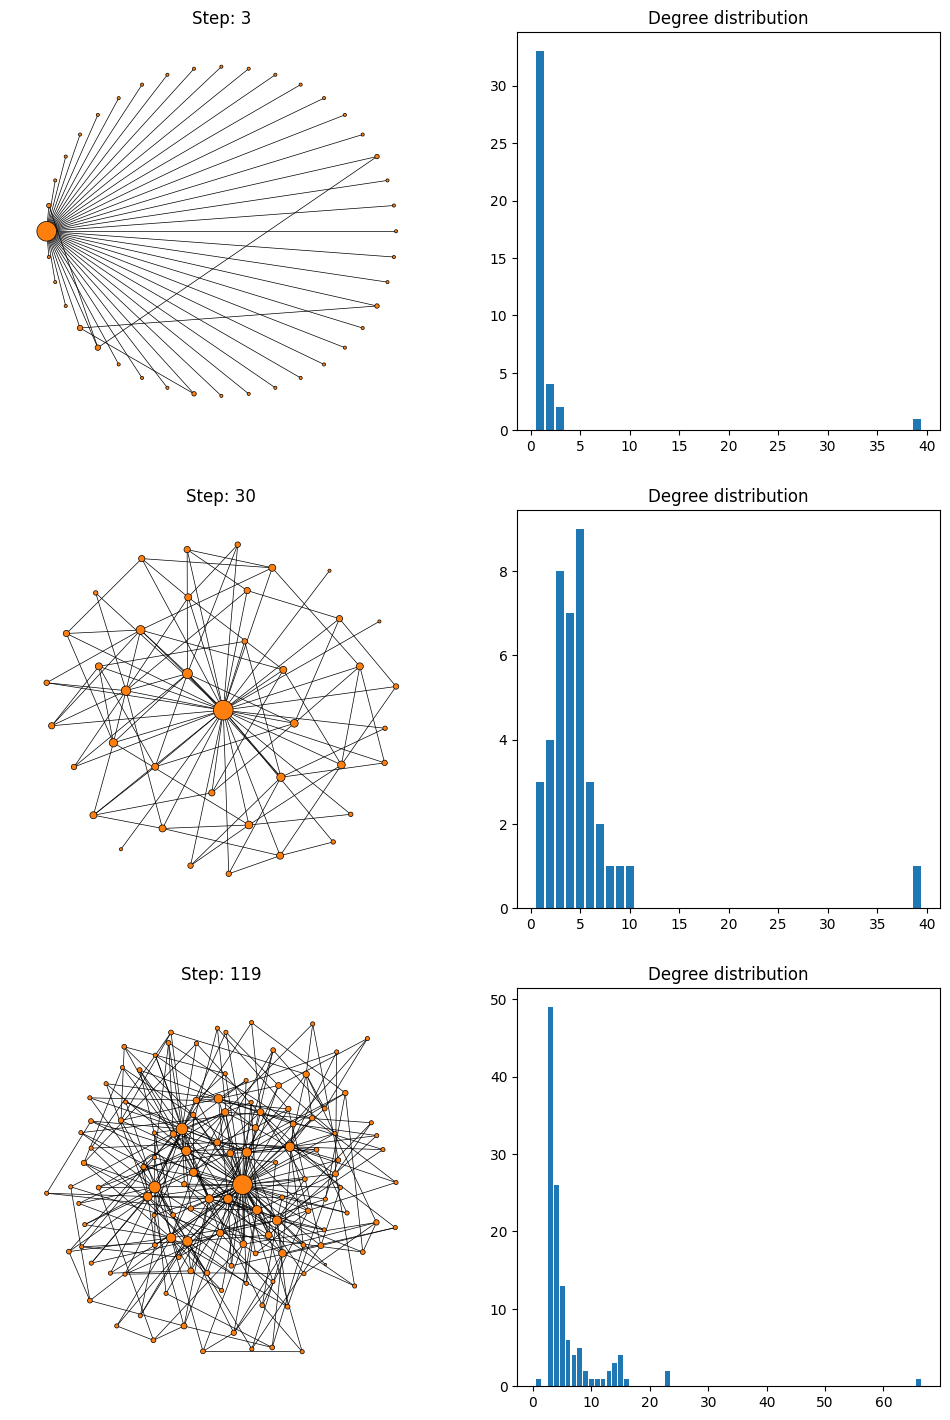

In [21]:
n, m = 123, 3
G = nx.star_graph(39)
plt.figure(figsize=(12, 6 * 5))
j = 1
for i in range(1, n - m):
    if i in [3, 30, n-m-1]:
        plt.subplot(5, 2, j)
        j += 1
        sizes = np.array(list(nx.degree_centrality(G).values()))
        sizes = sizes / max(sizes) * 200
        if i <= 3:
            pos = nx.layout.shell_layout(G)
        else:
            pos = nx.layout.kamada_kawai_layout(G)
        nx.draw(
            G,
            pos=pos,
            with_labels=False,
            node_size=sizes,
            width=0.5,
            linewidths=0.5,
            edgecolors='black',
            node_color='tab:orange')
        plt.title('Step: {}'.format(i))
        degree_seq = [degree for (node, degree) in G.degree]
        bins, freq = np.unique(degree_seq, return_counts=True)
        plt.subplot(5, 2, j)
        j += 1
        plt.bar(bins, freq)
        plt.title('Degree distribution')
    attach(m + i, G, m)

## Structural analysis
1. Network models comparison
    - ER (random graph) - my net is not similar to ER model according to clustering, degree distribution or any other structural parameter
    - BA (preferential attachment) - while structural properties look similar, BA model is leaning to make 1 strong community, when my net shows at least 4 obvious communities
    - WS (small-world) -  my net is not similar to WS model according to clustering (my < WS), degree distribution or any other structural parameter
2. Centrality measures
    - Degree centrality top node is id329115238, he is my best friend from the school. It is expected for him to have the most degree in my ego network because we share a lot of life experience and thus a lot of friends
    - Betweenness centrality top node is id171705539, she is my fiance and she added a lot of her friends into my ego net - the community of school friends is weakly connected with the community of fiance's friends
    - The top Closeness centrality node is again my best school friend id329115238
    - Top 5 nodes by Eigenvector centrality measure are counselors at my lovely children's camp

In [22]:
len(G.nodes), len(G.edges)

(123, 367)

In [23]:
# top nodes by Degree, Betweenness, Closeness, Eigenvector centrality
top_degree = sorted(nx.degree_centrality(g).items(), key=lambda x: x[1], reverse=True)[:5]
top_betweenness = sorted(nx.betweenness_centrality(g).items(), key=lambda x: x[1], reverse=True)[:5]
top_closeness = sorted(nx.closeness_centrality(g).items(), key=lambda x: x[1], reverse=True)[:5]
top_eigenvector = sorted(nx.eigenvector_centrality(g).items(), key=lambda x: x[1], reverse=True)[:5]

In [24]:
print(f"Top node by degree centrality: {top_degree}")
print(f"Top node by betweenness centrality: {top_betweenness}")
print(f"Top node by closeness centrality: {top_closeness}")
print(f"Top node by eigenvector centrality: {top_eigenvector}")

Top node by degree centrality: [('329115238', 0.21311475409836067), ('788473', 0.19672131147540983), ('20848418', 0.19672131147540983), ('153552036', 0.19672131147540983), ('87345513', 0.18032786885245902)]
Top node by betweenness centrality: [('171705539', 0.3004171421765347), ('75470808', 0.24814180684702666), ('329115238', 0.2105351340979137), ('247932292', 0.16382541314166138), ('20848418', 0.08467451505124444)]
Top node by closeness centrality: [('329115238', 0.2604861503674392), ('171705539', 0.25694212111073933), ('164398839', 0.24289705339729062), ('20848418', 0.23533016699862108), ('75470808', 0.2345993279706751)]
Top node by eigenvector centrality: [('153552036', 0.312985693343044), ('20848418', 0.30094761078865134), ('87345513', 0.2961323286535498), ('788473', 0.27867501238570574), ('329115238', 0.264110133943853)]


## Community detection

In [25]:
g = nx.read_gml('ego_net.gml')
g = nx.convert_node_labels_to_integers(g)
pos = nx.layout.kamada_kawai_layout(g)

### Hand-maid communities

In [26]:
node_atributes = (
    pd.read_csv("nodes.csv", index_col='Unnamed: 0')
    .assign(atributes_list=lambda x: x.atributes.str.split(','))
)
all_categories = []
for sublist in node_atributes['atributes_list']:
    if isinstance(sublist, list): # Ensure it's a list
        all_categories.extend(sublist)
unique_categories = sorted(list(set(all_categories)))

for category in unique_categories:
    node_atributes['atribute_' + category] = node_atributes['atributes_list'].apply(lambda x: 1 if isinstance(x, list) and category in x else 0)

atributes_dict = node_atributes.drop(columns=['atributes', 'atributes_list']).T.to_dict()
nx.set_node_attributes(g, atributes_dict)
g.nodes[0]

{'id': 170790404,
 'atribute_алина': 0,
 'atribute_викинг': 0,
 'atribute_вшэ': 0,
 'atribute_импульс': 0,
 'atribute_лис': 0,
 'atribute_матфак': 1,
 'atribute_миэм': 0,
 'atribute_семья': 0,
 'atribute_физмат': 1,
 'atribute_цдоош': 1,
 'atribute_чгк': 0,
 'atribute_школа': 0}

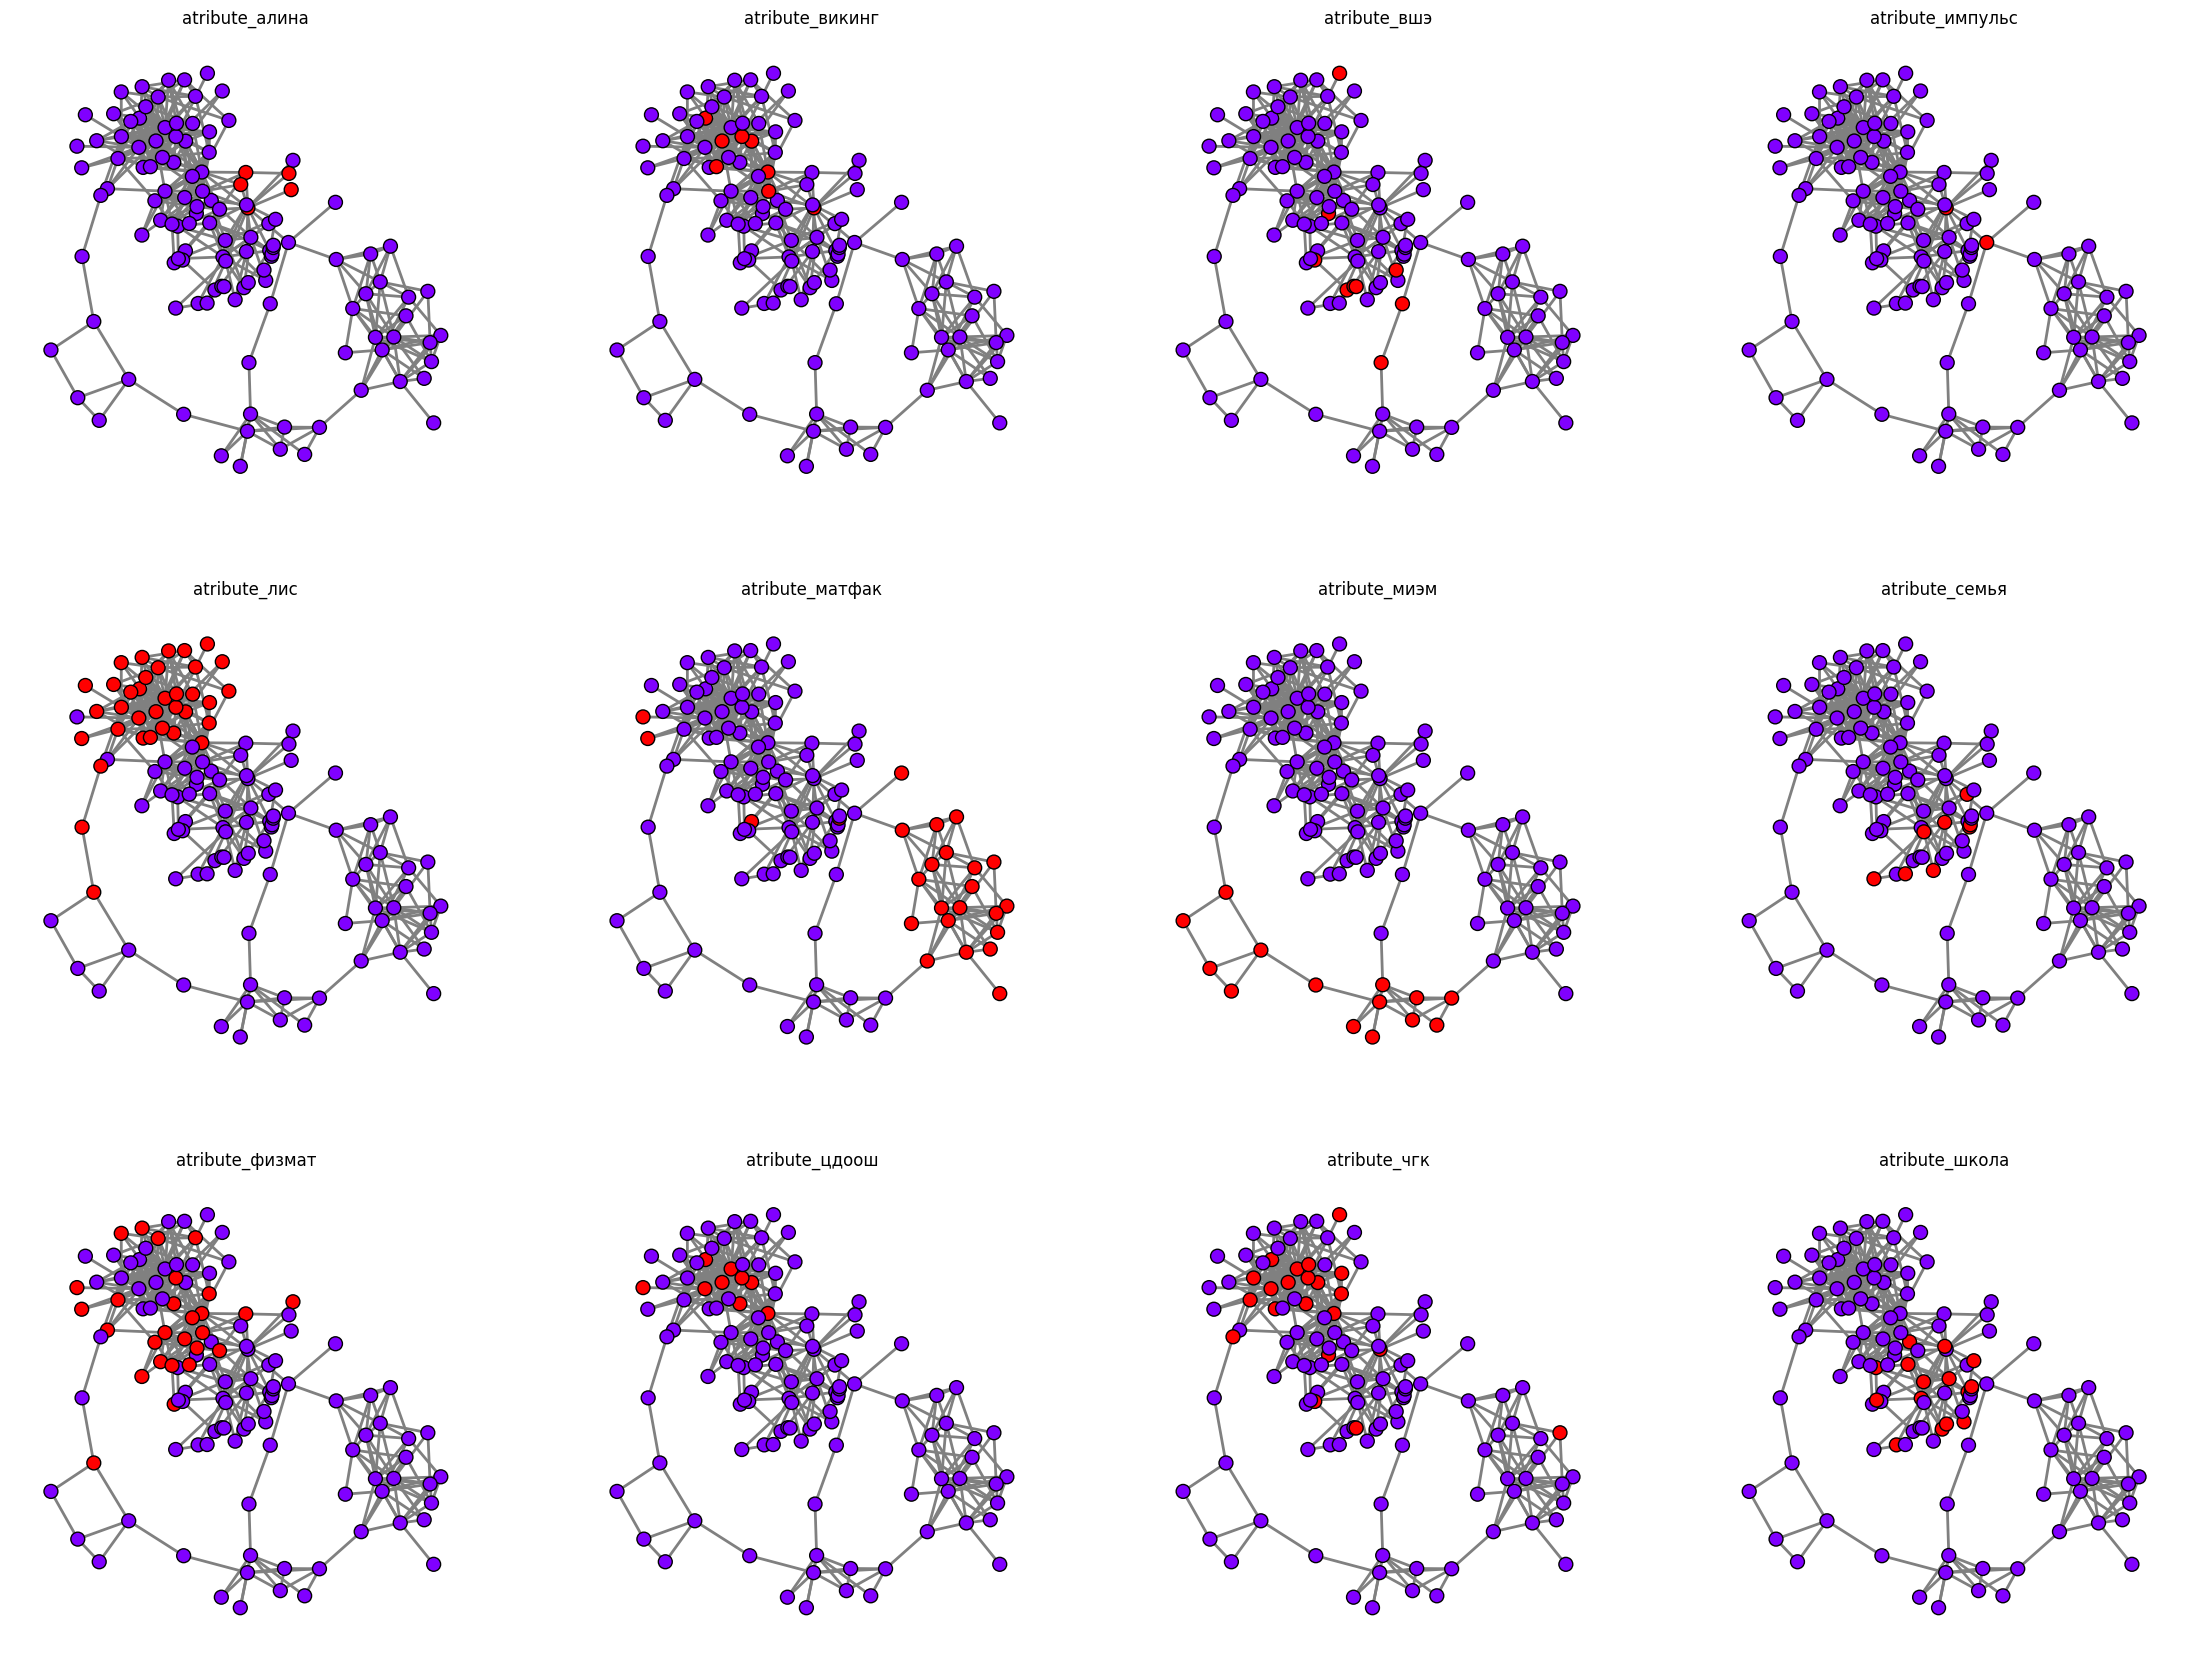

In [31]:
labels = [
    'atribute_алина',
    'atribute_викинг',
    'atribute_вшэ',
    'atribute_импульс',
    'atribute_лис',
    'atribute_матфак',
    'atribute_миэм',
    'atribute_семья',
    'atribute_физмат',
    'atribute_цдоош',
    'atribute_чгк',
    'atribute_школа',
]
l = len(labels)

plt.figure(figsize=(7*4, 7*((l + 1) // 4)))
for i, label in enumerate(labels):
    plt.subplot((l + 1) // 4, 4, i+1)
    nx.draw_networkx_nodes(
        g,
        pos,
        cmap=plt.cm.rainbow,
        node_color=[g.nodes[node][label] for node in g.nodes],
        node_size=100,
        edgecolors='black'
    )
    nx.draw_networkx_edges(g, pos, alpha=1, width=2, edge_color='grey')
    plt.title(label)
    plt.axis('off')

### Giant component

In [35]:
G = g.copy()

max_cc = max(nx.connected_components(G), key=len)
max_size = len(max_cc)

GCC = nx.subgraph(G, max_cc)
GCC = nx.convert_node_labels_to_integers(GCC, label_attribute='g_id')

gcc_pos = {node: pos[GCC.nodes[node]['g_id']] for node in GCC.nodes}
max_cc = max(nx.connected_components(G), key=len)
max_size = len(max_cc)


### Girvan-Newman algorithm
1. (all) partition Moscow - Kirov
2. (Moscow) partition миэм - матфак
3. (kirov) partition friendship - closest family
4. (миэм) partition classmates - dormitory
5. noises

In [36]:
def remove_bridges(G):
    n_cc = nx.number_connected_components(G)
    while nx.number_connected_components(G) == n_cc:
      e_betw = nx.edge_betweenness_centrality(G)
      G.remove_edge(*max(e_betw, key=e_betw.get))

def girvan_newman(G, n):
    labels = np.zeros((n, len(G)))
    _G = G.copy()
    for division in range(n):
        remove_bridges(_G)
        for i, cc in enumerate(nx.connected_components(_G)):
            labels[division, list(cc)] = i
    return labels

In [37]:
communities = girvan_newman(GCC, 6)

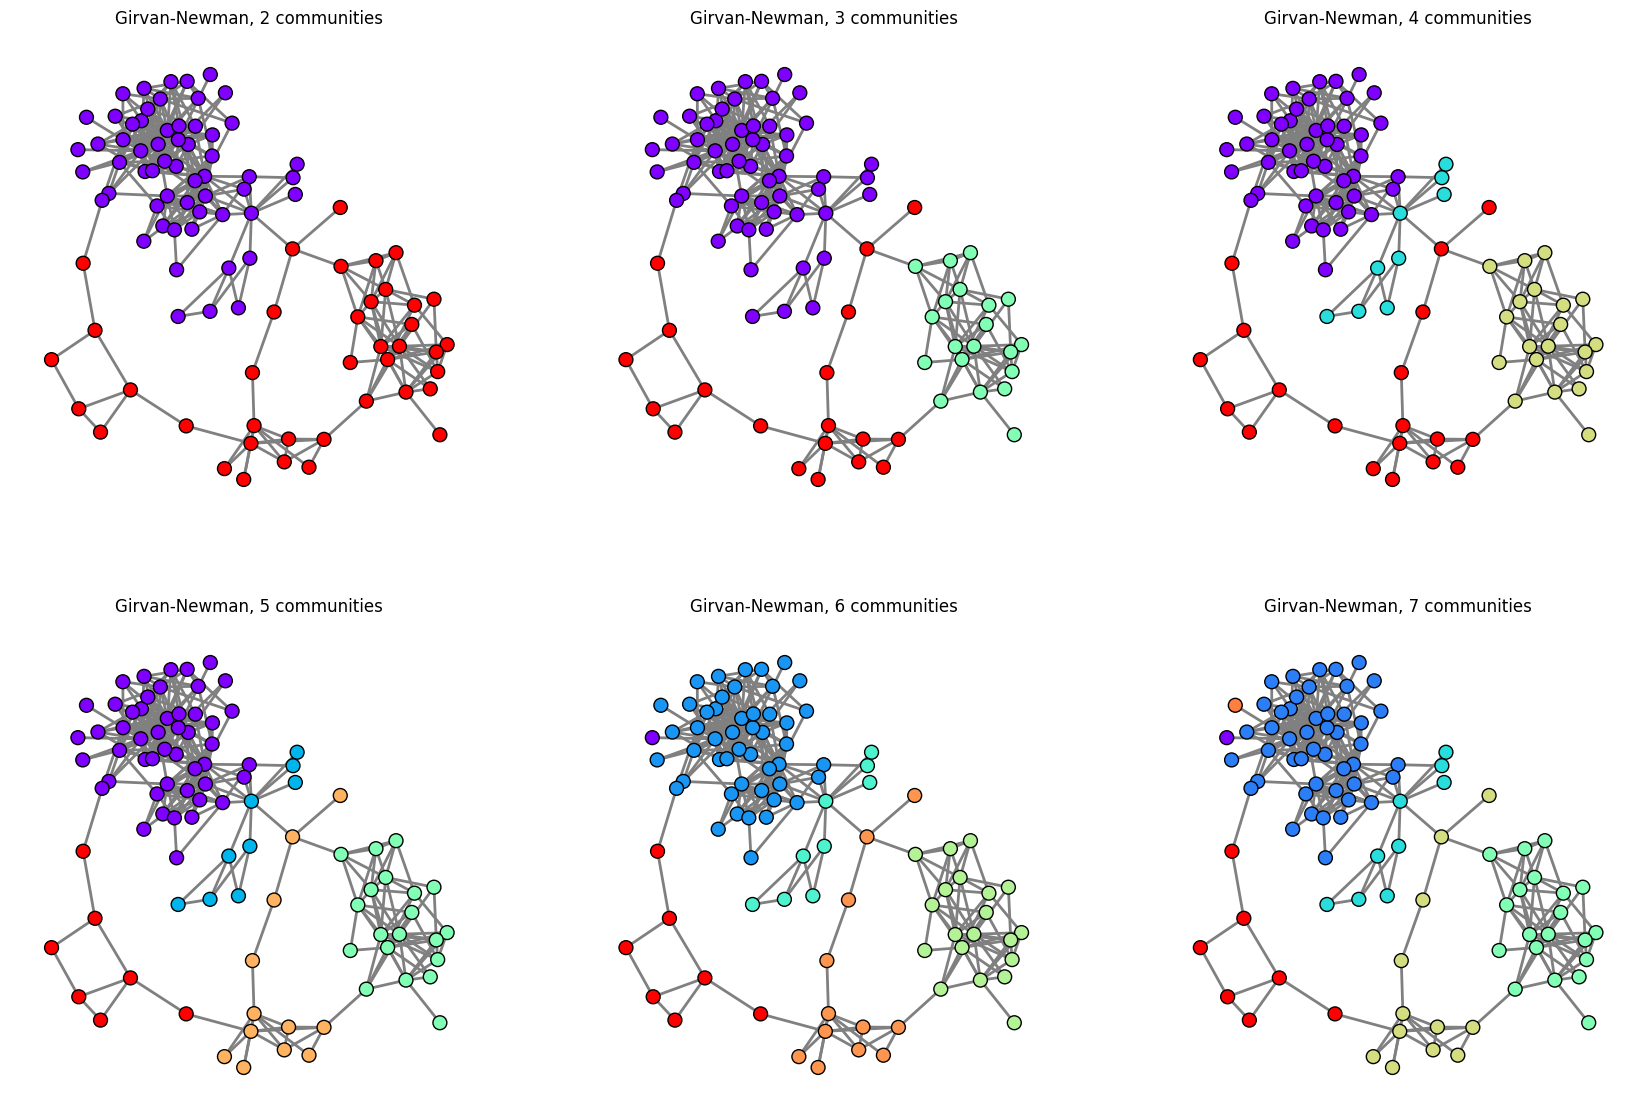

In [38]:
plt.figure(figsize=(7*3, 7*2))
for i in range(communities.shape[0]):
    plt.subplot(2, 3, i+1)
    nx.draw_networkx_nodes(
        GCC,
        gcc_pos,
        cmap=plt.cm.rainbow,
        node_color=communities[i],
        node_size=100,
        edgecolors='black'
    )
    nx.draw_networkx_edges(GCC, gcc_pos, alpha=1, width=2, edge_color='grey')
    plt.title('Girvan-Newman, {} communities'.format(i+2))
    plt.axis('off')

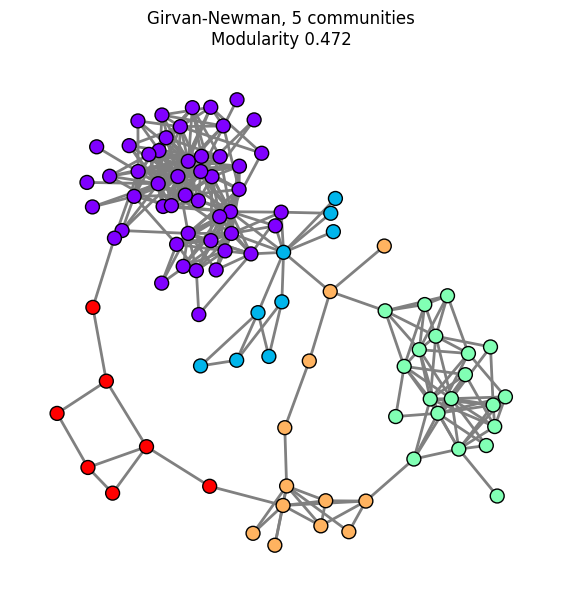

In [42]:
girvan_newman_labels = communities[3]
n_comm = len(set(girvan_newman_labels))

comms = [[] for _ in range(girvan_newman_labels.astype(int).max() + 1)]
for i, label in enumerate(girvan_newman_labels.astype(int)):
    comms[label].append(i)


plt.figure(figsize=(7, 7))
nx.draw_networkx_nodes(
    GCC,
    gcc_pos,
    cmap=plt.cm.rainbow,
    node_color=girvan_newman_labels,
    node_size=100,
    edgecolors='black'
)
nx.draw_networkx_edges(GCC, gcc_pos, alpha=1, width=2, edge_color='grey')
plt.title(f'Girvan-Newman, {n_comm} communities\nModularity {nx.community.modularity(GCC, comms):.3f}')
_ = plt.axis('off')

### Label propogation
- chaotic, not robust
- extremely dependant on initial randomnes
- performs better in terms of modularity

In [43]:
def async_update_labels(graph, labels):
    current_labels = np.copy(labels)
    nodes = list(graph.nodes())
    random.shuffle(nodes,)

    for node in nodes:
        neighbors = list(graph.neighbors(node))

        if neighbors:
            neighbor_labels = [current_labels[n] for n in neighbors]

            counts = Counter(neighbor_labels)

            max_freq = 0
            if counts:
                max_freq = max(counts.values())

            most_frequent_labels = [label for label, freq in counts.items() if freq == max_freq]

            if most_frequent_labels:
                current_labels[node] = random.choice(most_frequent_labels)

    return current_labels

In [49]:
def plot_propagation(G, update_method, n=50, seed=1):
    pos=nx.kamada_kawai_layout(G)
    labels = np.array(list(G.nodes))
    random.seed(seed)
    for i in range(n):
        clear_output(wait=True)
        labels = update_method(G, labels)
        plt.figure(figsize=(8, 8))
        nx.draw_networkx_nodes(
            G,
            pos=pos,
            node_color=labels,
            cmap=plt.cm.rainbow,
            node_size=100,
            edgecolors='black'
        )
        
        comms = [[] for _ in range(labels.astype(int).max() + 1)]
        for j, label in enumerate(labels.astype(int)):
            comms[label].append(j)
        
        nx.draw_networkx_edges(G, pos=pos, alpha=0.2)
        plt.axis('off')
        plt.title(
            'Iteration {}/{}\nModularity {:.3f}'
            .format(
                i+1, n, 
                nx.community.modularity(G, comms)
            )
            )
        plt.show()
    return labels

#### examples of chaos

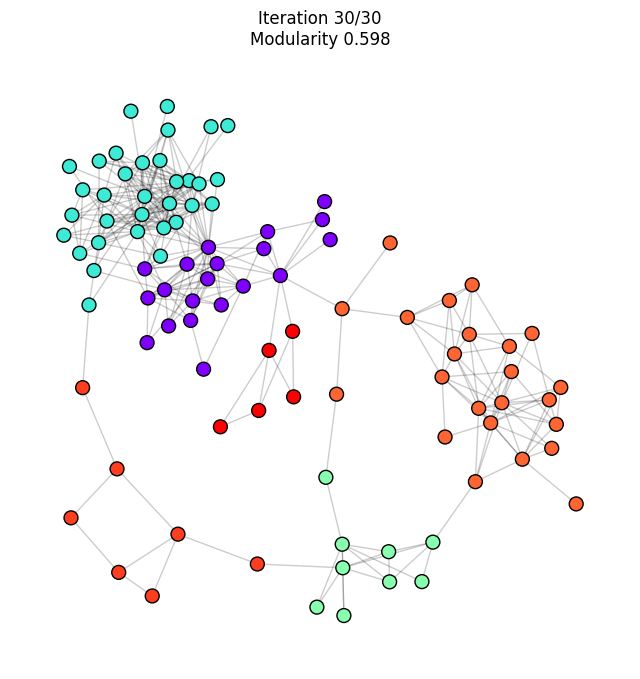

In [50]:
label_prop_communities = plot_propagation(GCC, async_update_labels, 30, seed=1)

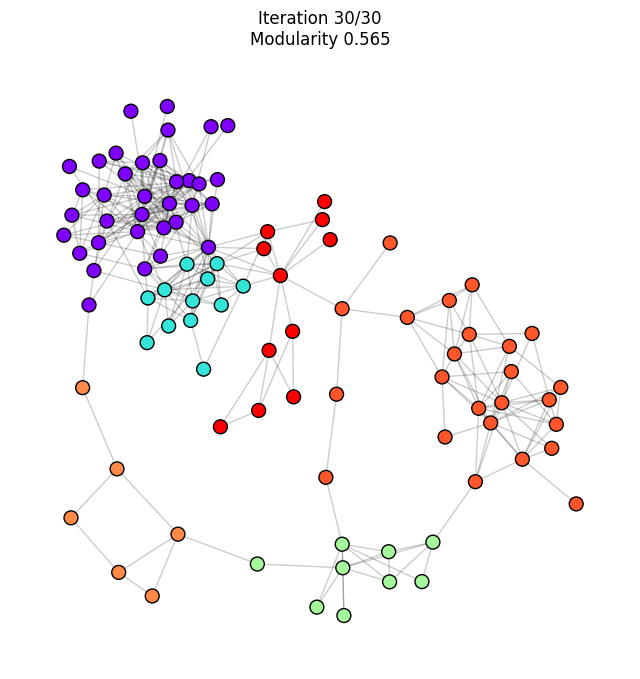

In [51]:
label_prop_communities = plot_propagation(GCC, async_update_labels, 30, seed=5)

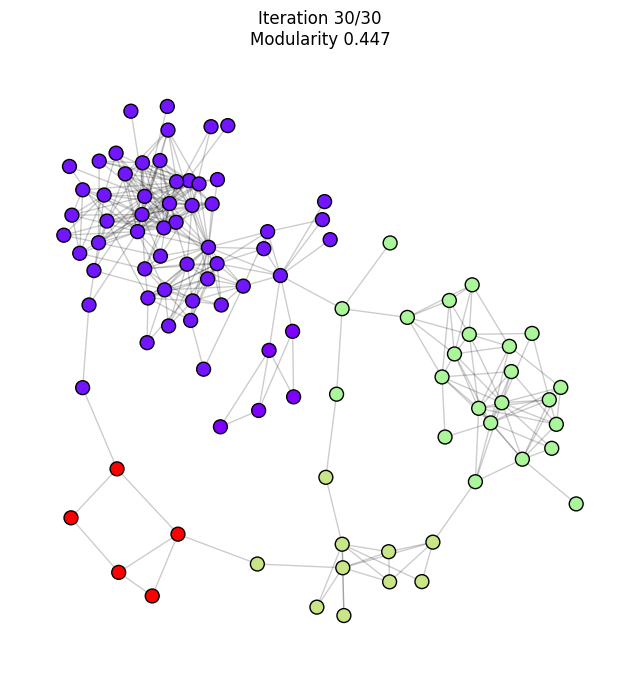

In [52]:
label_prop_communities = plot_propagation(GCC, async_update_labels, 30, seed=3)

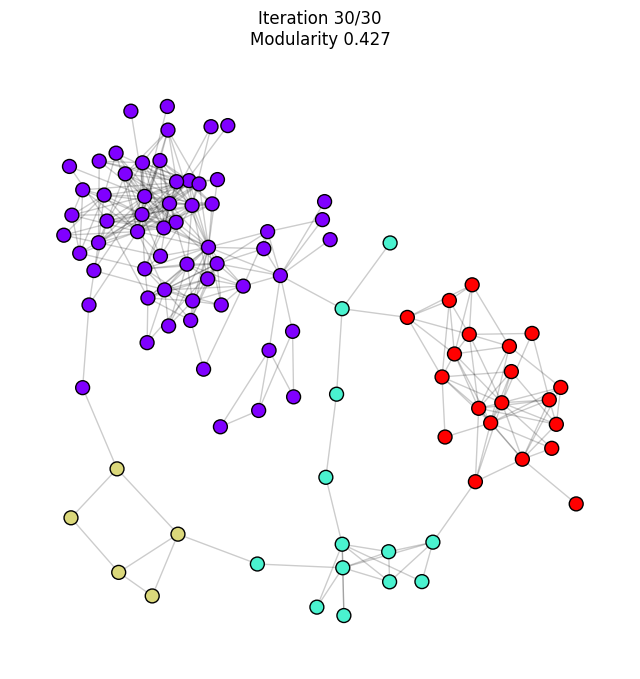

In [53]:
label_prop_communities = plot_propagation(GCC, async_update_labels, 30, seed=4)

### Louvain method
- improves modularity

In [49]:
def expected_edges(A, m):
    return A.sum(axis=1, keepdims=True) * A.sum(axis=0, keepdims=True) / (2 * m)

def modularity_gain(A, ee, mnode, old_comm, new_comm, m):
    new_gain = (A[mnode, new_comm] - ee[mnode, new_comm]).sum() / m
    old_gain = (A[mnode, old_comm] - ee[mnode, old_comm]).sum() / m

    return new_gain - old_gain

def louvain_method(G):

    # Phase 1: community unfolding
    communities = unfolded_communities(G)

    # Create labels
    labels = np.zeros(len(G))
    for i, c in enumerate(communities):
        labels[c] = i

    # Phase 2: network aggregation
    nextG = nx.empty_graph(len(communities), nx.MultiGraph)
    for e in G.edges:
        nextG.add_edge(labels[int(e[0])], labels[int(e[1])])

    return communities, labels, nextG

def unfolded_communities(G):
    # Proposed template:
    A = nx.to_numpy_array(G)
    m = A.sum() / 2
    ee = expected_edges(A, m)
    communities = [[n] for n in G.nodes] # initial partition
    max_modularity_gain = 1
    while max_modularity_gain > 0:
        for node in G.nodes:
            '''
            1) Remove the node from the initial community.
            2) Iterate all neighboring communities and put a node
               in the community with maximal modularity gain. If
               there is no modularity gain, return the node into
               the initial community.
            '''
            # find old community
            comm_i = None
            i = 0
            while comm_i is None:
                if node in communities[i]:
                    comm_i = i
                i += 1

            # remove from old community
            communities[comm_i] = [x for x in communities[comm_i] if x != node]
            old_comm = communities[comm_i]

            # find best new community
            max_modularity_gain = 0
            best_comm_i = comm_i
            for new_comm_i in range(len(communities)):
                if new_comm_i != comm_i:
                    new_comm = communities[new_comm_i]
                    gain = modularity_gain(A, ee, node, old_comm, new_comm, m)
                    if gain > max_modularity_gain:
                        max_modularity_gain = gain
                        best_comm_i = new_comm_i
            # add node to the best community
            communities[best_comm_i].append(node)

    return [c for c in communities if len(c)]

In [50]:
iterG = GCC.copy()
prev_comm, labels, iterG = louvain_method(iterG)
for i in range(2):
    next_comm, labels, iterG = louvain_method(iterG)
    communities = []
    for c in next_comm:
        temp = []
        for node in c:
            temp.extend(prev_comm[node])
        communities.append(temp)
    prev_comm = communities.copy()
labels = np.zeros(len(GCC))
for i, c in enumerate(communities):
    labels[c] = i

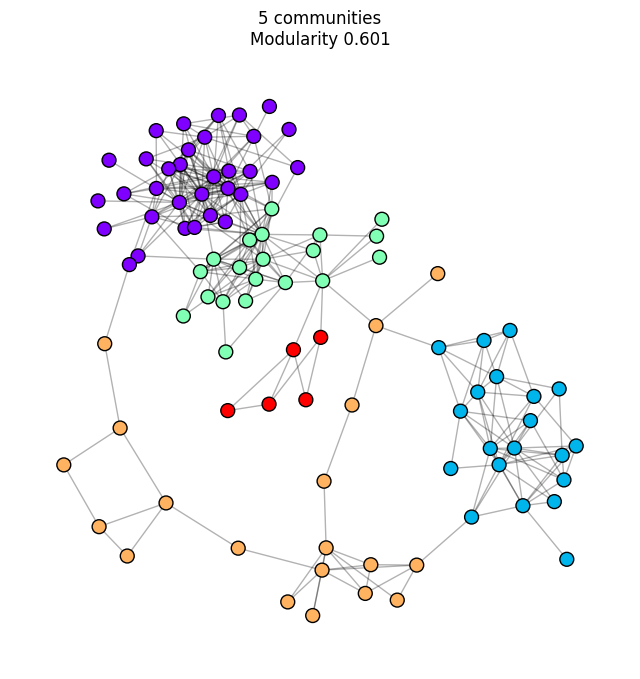

In [105]:
plt.figure(figsize=(8, 8))
nx.draw_networkx_nodes(
    GCC,
    gcc_pos,
    cmap=plt.cm.rainbow,
    node_color=labels,
    node_size=100,
    edgecolors='black'
)
nx.draw_networkx_edges(GCC, gcc_pos, alpha=0.3)
plt.title(
    '{} communities\nModularity {:.3f}'.format(
        len(communities),
        nx.community.modularity(GCC, communities)
    )
)
plt.axis('off');